## Sanity check: artefact removal

In [ ]:
# Change params here as you need
base_dir = "/Users/skuroda/Workstation2026/stiminterp/examples"
# where the raw data is saved

In [2]:
import matplotlib.pyplot as plt

%matplotlib inline
from pathlib import Path

from ScanImageTiffReader import ScanImageTiffReader

from stiminterp import remove_photostim_artefacts
from stiminterp.load_data.custom_data_loader import get_artefact_dfs
from stiminterp.plotting_hooks.sanity_check import (
    create_sanitycheck_axes,
    plot_removal,
)

si_tif = f"{base_dir}/20260303_121516__file_00001.tif"
si_h5 = f"{base_dir}/20260303_121516__file_00001.h5"

In [3]:
vol = ScanImageTiffReader(si_tif).data()
df_frames, df_stims = get_artefact_dfs(
    Path(si_h5), "FrameTTL", "SatsumaGateTTL"
)

In [4]:
corrected, bad_mask, df_split = remove_photostim_artefacts(
    vol, df_frames, df_stims, frame_gap=0, num_channel=2
)

In [5]:
df_split

,frame,frac_start,frac_stop
0,101,0.398148,0.490741
1,307,0.122642,0.216981
2,459,0.198113,0.292453
3,595,0.635514,0.728972
4,781,0.679245,0.764151
5,943,0.707547,0.792453
6,1138,0.214953,0.317757
7,1322,0.801887,0.886792
8,1505,0.231481,0.324074
9,1695,0.682243,0.775701


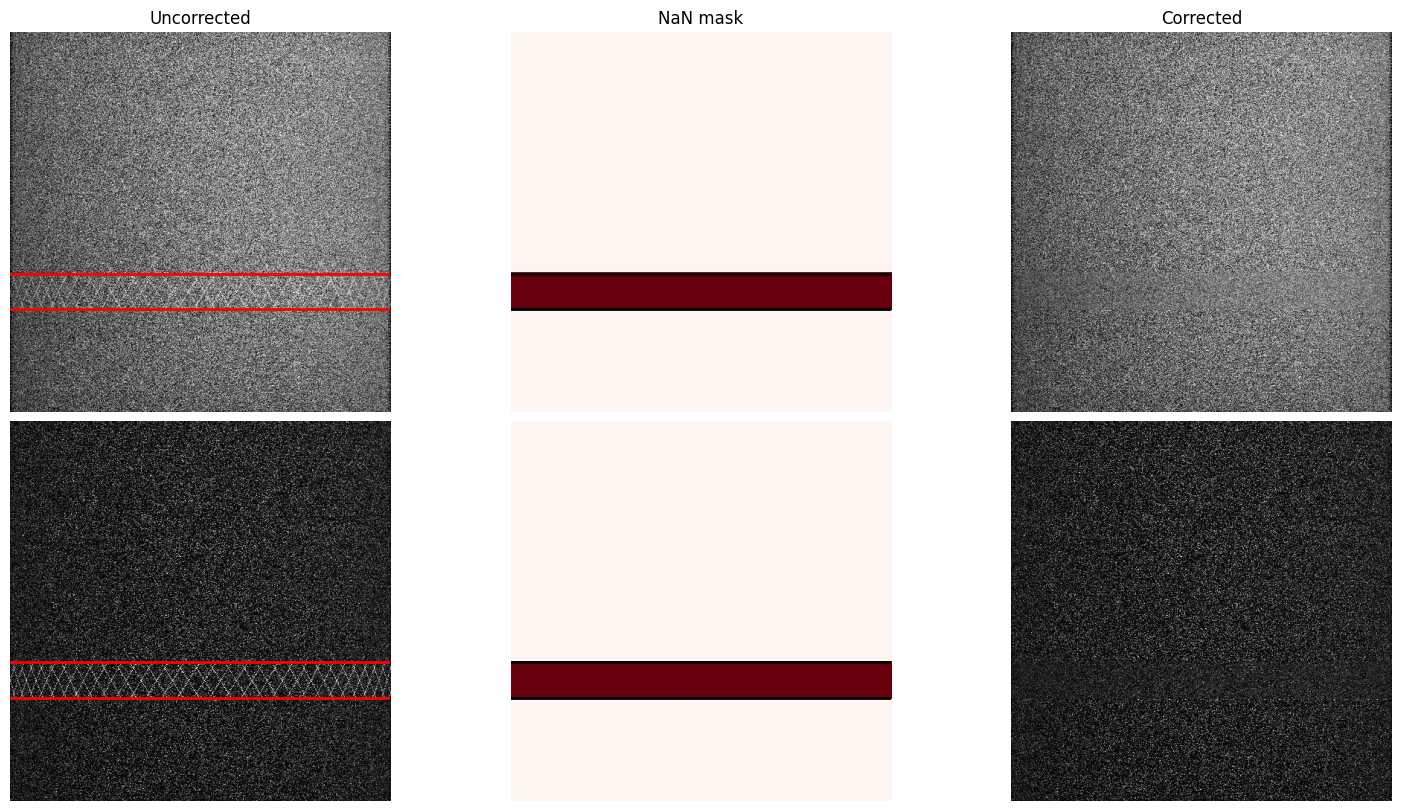

In [6]:
num_channel = 2

i = 3

fig, axes = create_sanitycheck_axes(num_channel)
for ch in range(num_channel):
    ttl_frame = df_split.frame[i]
    movie_frame = ttl_frame * num_channel + ch

    plot_removal(
        axes_row=axes[ch],
        frame=movie_frame,
        y_frac_start=df_split.frac_start[i],
        y_frac_stop=df_split.frac_stop[i],
        uncorrected=vol,
        corrected=corrected,
        bad_mask=bad_mask,
        channel=ch,
    )

plt.show()